# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 4. Demonstração (Demonstration)

**Objetivo Acadêmico:** Este notebook demonstra a aplicação do algoritmo **k-Nearest Neighbors (kNN)** como um modelo de base não-linear. O kNN baseia-se na hipótese de que dias com características similares (reserva, clima, cardápio) apresentam consumos similares. Conforme Hevner et al. (2004), a diversidade de métodos de avaliação é essencial para validar a robustez do artefato preditivo construído no ciclo de design.


# 07b - Modelagem: k-Nearest Neighbors (kNN)
Neste notebook, utilizamos o algoritmo **KNeighborsRegressor**.

**Estratégia**: O kNN é extremamente sensível à maldição da dimensionalidade. Por isso, utilizaremos **RFECV** para selecionar as variáveis mais importantes antes de calcular as distâncias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 191 registros.


In [2]:
# Validação da Base 2023-2025
print(f"📊 Shape da base: {df.shape}")
print(f"📅 Período: {df['data'].min()} até {df['data'].max()}")

📊 Shape da base: (191, 52)
📅 Período: 2023-08-01 00:00:00 até 2025-08-22 00:00:00


In [3]:
# 1. Divisão Treino/Teste (Temporal)
train_size = int(len(df) * 0.8)
X_full = df.drop(columns=['data', TARGET])
y_full = df[TARGET]

X_train_full = X_full.iloc[:train_size]
y_train = y_full.iloc[:train_size]
X_test_full = X_full.iloc[train_size:]
y_test = y_full.iloc[train_size:]

# 2. Seleção de Variáveis (RFECV)
print("🔄 Selecionando variáveis via RFECV para kNN...")
rf = RandomForestRegressor(n_estimators=50, random_state=42)
selector = RFECV(estimator=rf, step=1, cv=5, scoring='neg_mean_absolute_error')
selector.fit(X_train_full, y_train)

selected_features = X_full.columns[selector.support_].tolist()
print(f"✅ RFECV concluído! Variáveis: {len(selected_features)}")

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

# 3. Normalização (CRUCIAL para kNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

🔄 Selecionando variáveis via RFECV para kNN...
✅ RFECV concluído! Variáveis: 5
📈 Treino: 152 dias | Teste: 39 dias


In [4]:
# Testando diferentes valores de K, pesos e métricas de distância
# Adicionando Manhattan (p=1) que é mais robusta em muitos casos
params_k = [2, 3, 4, 5, 6]
params_p = [1, 2]  # 1: Manhattan, 2: Euclidean
results = []

for k in params_k:
    for weight in ['uniform', 'distance']:
        for p_val in params_p:
            model = KNeighborsRegressor(n_neighbors=k, weights=weight, p=p_val)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
            
            mae = mean_absolute_error(y_test, preds)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)
            
            results.append({
                'K': k, 
                'Weights': weight, 
                'Metric': 'Manhattan' if p_val == 1 else 'Euclidean',
                'MAE': mae, 
                'RMSE': rmse, 
                'R2': r2
            })

df_results = pd.DataFrame(results).sort_values('MAE')
display(df_results.head(10))

,K,Weights,Metric,MAE,RMSE,R2
17,6,uniform,Euclidean,23.683761,31.373610,0.234078
19,6,distance,Euclidean,24.250184,31.901158,0.208103
13,5,uniform,Euclidean,24.851282,33.621117,0.120411
12,5,uniform,Manhattan,24.892308,31.262659,0.239485
16,6,uniform,Manhattan,24.982906,31.540075,0.225928
15,5,distance,Euclidean,25.120454,33.697523,0.116408
14,5,distance,Manhattan,25.533460,31.871275,0.209586
4,3,uniform,Manhattan,25.564103,31.888561,0.208728
18,6,distance,Manhattan,25.703384,32.112308,0.197585
8,4,uniform,Manhattan,25.756410,31.631188,0.221450


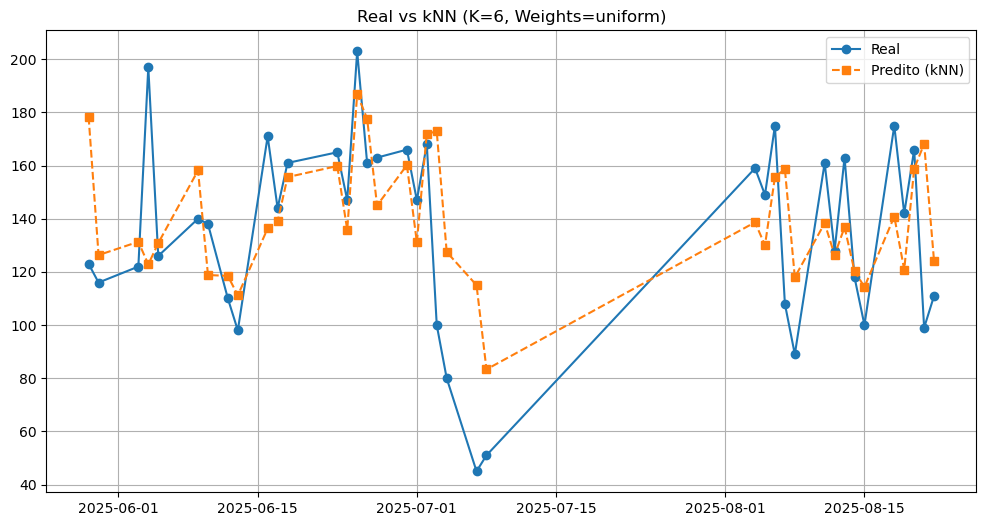

In [5]:
best = df_results.iloc[0]
model = KNeighborsRegressor(n_neighbors=int(best['K']), weights=best['Weights'])
model.fit(X_train_scaled, y_train)
final_preds = model.predict(X_test_scaled)

plt.figure(figsize=(12, 6))
plt.plot(df.iloc[train_size:]['data'], y_test, label='Real', marker='o')
plt.plot(df.iloc[train_size:]['data'], final_preds, label='Predito (kNN)', linestyle='--', marker='s')
plt.title(f"Real vs kNN (K={best['K']}, Weights={best['Weights']})")
plt.legend()
plt.grid(True)
plt.show()